#Fashin MNIST
Fashion Mnist는 옷, 바지 등 10가지 종류의 의류로 구성된 데이터입니다. 이 데이터는 (28, 28) 크기로 구성되어 있으며 Training Set 6만장, Test Set 1만장으로 총합 7만장으로 이루어져 있습니다. Keras에서 dataset을 import 할 수 있고, 처음 import 시 다운로드 하는 과정이 추가됩니다.

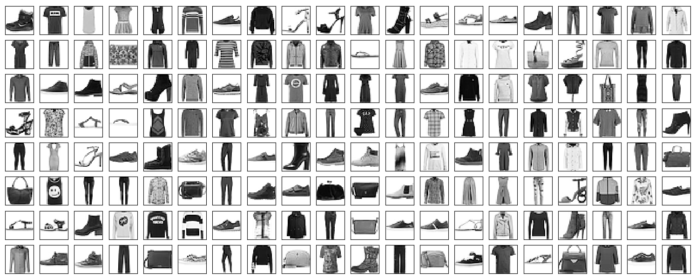


In [1]:
from tensorflow.keras import datasets, layers, models, utils
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train2d, y_train),(x_test2d, y_test) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(x_train2d.shape, y_train.shape)
print(x_test2d.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [4]:
items = {0:'T-shirt/top', 1:'Trouser', 2:'Pullover', 3:'Dress',
         4:'Coat', 5:'Sandal', 6:'Shirt', 7:'Sneaker',
         8:'Bag', 9:'Ankel boot'}

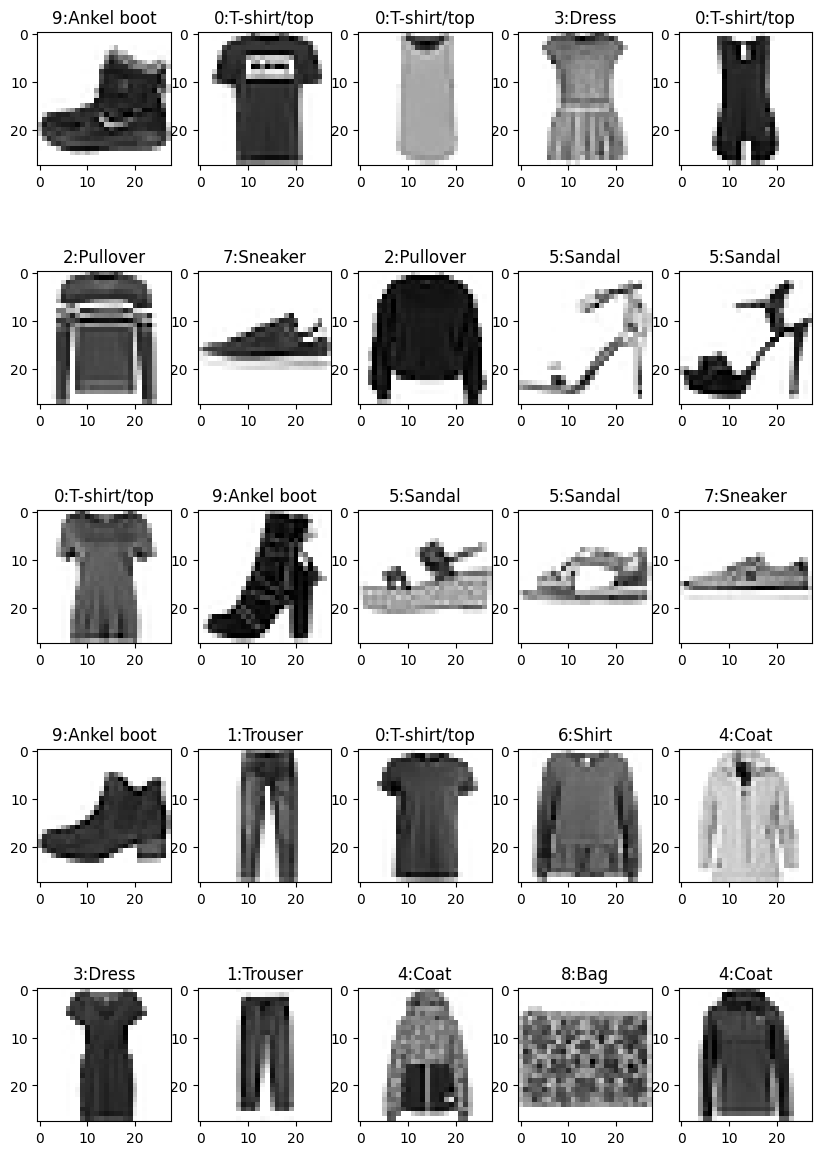

In [5]:
fig, axs = plt.subplots(5, 5, figsize=(10,15))
for i in range(5):
  for j in range(5):
    axs[i, j].set_title('{}:{}'.format(y_train[i*5+j], items[y_train[i*5+j]]))
    axs[i, j].imshow(x_train2d[i*5+j], cmap='gray_r')
plt.show()

In [6]:
# 채널 추가
x_train = x_train2d.reshape(-1, 28, 28, 1)
x_test = x_test2d.reshape(-1, 28, 28, 1)

In [7]:
# 정규화(0-1사이 값으로 바꿈)
x_train = x_train / 255
x_test = x_test / 255

#모델구성

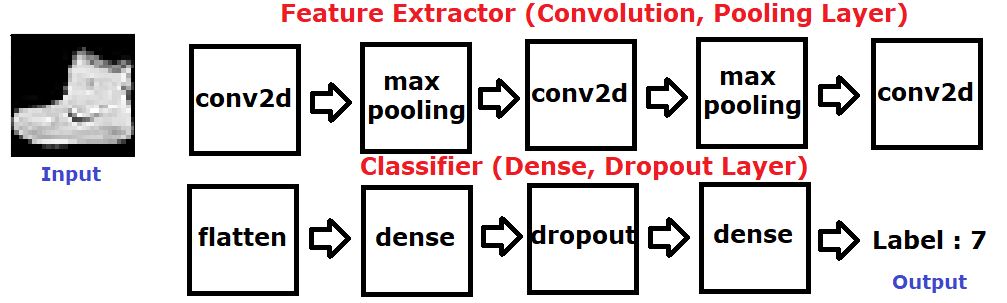

## Feature Extractor

In [8]:
# 32 - 64 - 128 - dropout(0.3)
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPool2D((2, 2), strides=2))
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPool2D((2, 2), strides=2))
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,672 (362.00 KB)

 Trainable params: 92,672 (362.00 KB)

 Non-trainable params: 0 (0.00 B)

### Classifier

In [10]:
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(10, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])
# sparse_categorical_crossentropy: 정수 라벨(0,1,2,…)을 그대로 사용할 때 쓰는 다중 분류용 손실 함수
# 라벨이 이렇게 생겼을 때 (y_train = [0, 1, 2, 3, ...]) 원-핫 인코딩 안하고 그냥 숫자 그대로 사용

In [12]:
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - acc: 0.8323 - loss: 0.4623 - val_acc: 0.8783 - val_loss: 0.3266
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.8926 - loss: 0.2975 - val_acc: 0.9033 - val_loss: 0.2605
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9080 - loss: 0.2505 - val_acc: 0.9067 - val_loss: 0.2469
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9201 - loss: 0.2170 - val_acc: 0.9114 - val_loss: 0.2349
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9305 - loss: 0.1904 - val_acc: 0.9188 - val_loss: 0.2254
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9361 - loss: 0.1713 - val_acc: 0.9102 - val_loss: 0.2574
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9454 - loss: 0.1468 - val_acc: 0.9199 - val_loss: 0.2391
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9502 - loss: 0.1302 - val_acc: 0.9178 - val_loss: 0.2468
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━

In [21]:
def plot_history(history):
  plt.figure(figsize=(15,5))
  plt.subplot(1,2,1)
  plt.plot(history['acc'])
  plt.plot(history['val_acc'])
  plt.legend(['train', 'validation'])
  plt.title('Acc')
  plt.subplot(1,2,2)
  plt.plot(history['loss'])
  plt.plot(history['val_loss'])
  plt.legend(['train', 'validation'])
  plt.title('Loss')
  plt.show()

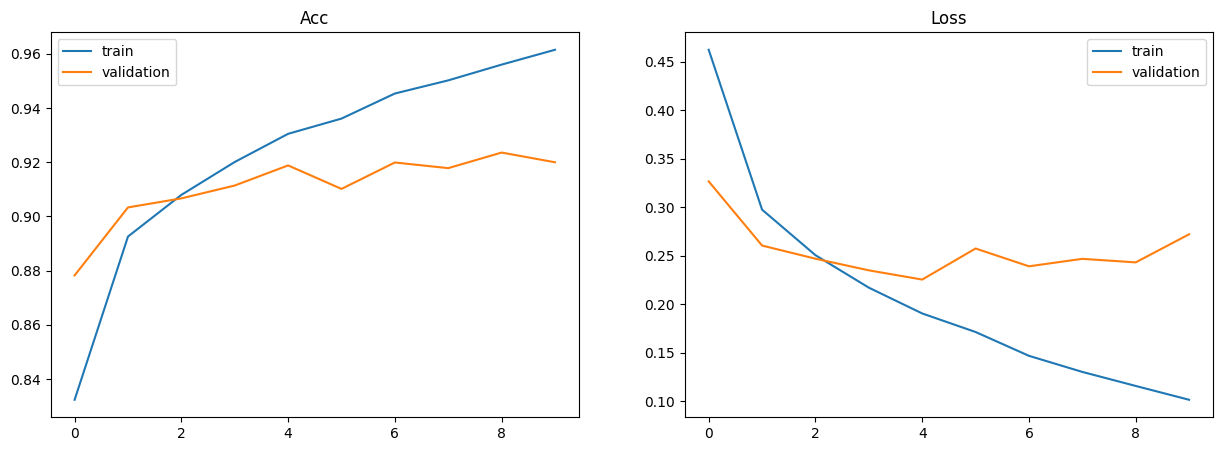

In [22]:
plot_history(history.history)

#Drop out
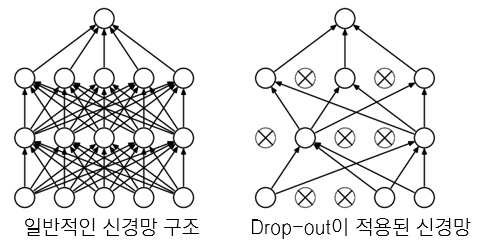

## BatchNormalization
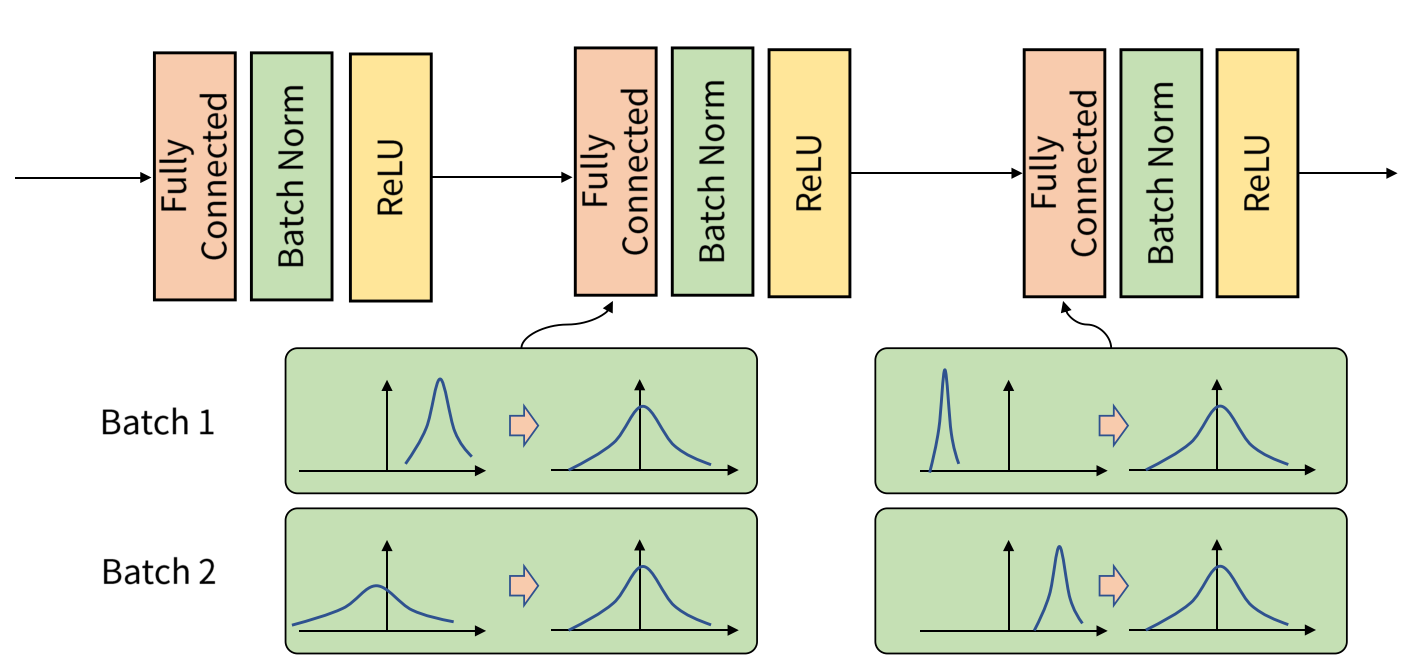

In [ ]:
# BatchNormalization (배치 정규화) : 각 층의 출력값을 정규화해서 학습을 더 빠르고 안정적으로 만드는 기법
# 학습 중에 각 층의 출력 분포가 계속 바뀌는 것을 값을 일정한 범위로 맞춰주는 것
# 데이터가 한쪽으로 몰리는 것을 막음. 과적합 방지

In [23]:
model2 = models.Sequential()
model2.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)))
model2.add(layers.BatchNormalization())

model2.add(layers.MaxPool2D((2, 2), strides=2))
model2.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model2.add(layers.BatchNormalization())

model2.add(layers.MaxPool2D((2, 2), strides=2))
model2.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model2.add(layers.Flatten())
model2.add(layers.Dense(128, activation='relu'))
model2.add(layers.Dropout(0.3))
model2.add(layers.Dense(10, activation='softmax'))
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

In [24]:
model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [25]:
history2 = model2.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - acc: 0.8564 - loss: 0.4064 - val_acc: 0.8890 - val_loss: 0.3027
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9012 - loss: 0.2756 - val_acc: 0.9038 - val_loss: 0.2557
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9128 - loss: 0.2353 - val_acc: 0.8941 - val_loss: 0.2755
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - acc: 0.9220 - loss: 0.2091 - val_acc: 0.9145 - val_loss: 0.2304
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9294 - loss: 0.1881 - val_acc: 0.9104 - val_loss: 0.2535
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - acc: 0.9373 - loss: 0.1692 - val_acc: 0.9021 - val_loss: 0.3030
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - acc: 0.9425 - loss: 0.1514 - val_acc: 0.9175 - val_loss: 0.2393
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9501 - loss: 0.1344 - val_acc: 0.9122 - val_loss: 0.2878
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━

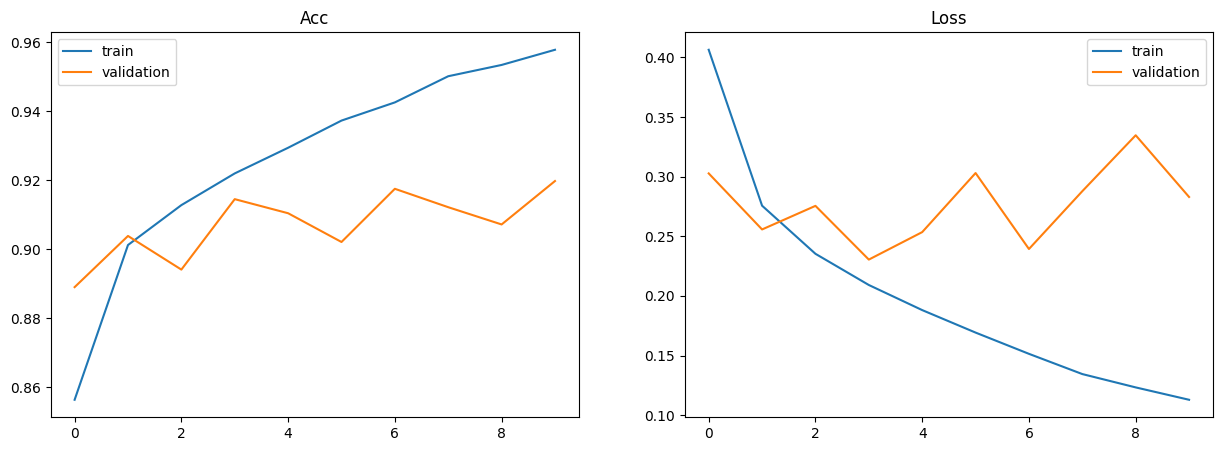

In [26]:
plot_history(history2.history)

In [28]:
model2.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.9159 - loss: 0.3105


[0.3104732036590576, 0.9158999919891357]

## Callback

In [ ]:
# 학습 중 자동으로 개입하는 기능들 모음
# model.fit()이 돌아가는 동안 중간중간 끼어들어서 기록 / 조기 종료 / 저장 / 학습률 조정 같은 일을 해준다

In [29]:
model3 = models.Sequential()
model3.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)))
model3.add(layers.BatchNormalization())

model3.add(layers.MaxPool2D((2, 2), strides=2))
model3.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model3.add(layers.BatchNormalization())

model3.add(layers.MaxPool2D((2, 2), strides=2))
model3.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model3.add(layers.Flatten())
model3.add(layers.Dense(128, activation='relu'))
model3.add(layers.Dropout(0.3))
model3.add(layers.Dense(10, activation='softmax'))
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

In [30]:
model3.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [31]:
# 가장 성능 좋은 모델 자동 저장
checkpoint_cb = keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True)
history3 = model3.fit(x_train, y_train, epochs=10, validation_split=0.2, callbacks=[checkpoint_cb])

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - acc: 0.8555 - loss: 0.4061 - val_acc: 0.8937 - val_loss: 0.2897
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.8992 - loss: 0.2791 - val_acc: 0.9012 - val_loss: 0.2728
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9139 - loss: 0.2364 - val_acc: 0.9082 - val_loss: 0.2493
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9225 - loss: 0.2113 - val_acc: 0.9143 - val_loss: 0.2453
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9305 - loss: 0.1865 - val_acc: 0.9102 - val_loss: 0.2724
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9365 - loss: 0.1693 - val_acc: 0.9140 - val_loss: 0.2456
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9430 - loss: 0.1537 - val_acc: 0.9073 - val_loss: 0.2854
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9493 - loss: 0.1344 - val_acc: 0.9193 - val_loss: 0.2656
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━

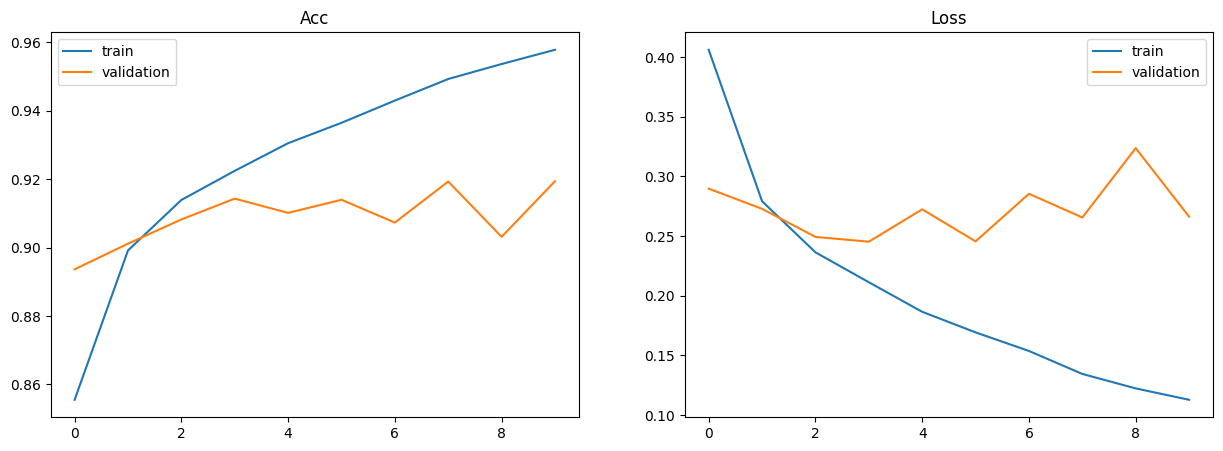

In [32]:
plot_history(history3.history)

In [33]:
model3.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9138 - loss: 0.2931


[0.2930530905723572, 0.9138000011444092]

In [34]:
model4 = models.Sequential()
model4.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)))
model4.add(layers.BatchNormalization())
model4.add(layers.MaxPool2D((2, 2), strides=2))
model4.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model4.add(layers.BatchNormalization())
model4.add(layers.MaxPool2D((2, 2), strides=2))
model4.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model4.add(layers.Flatten())
model4.add(layers.Dense(128, activation='relu'))
model4.add(layers.Dropout(0.3))
model4.add(layers.Dense(10, activation='softmax'))
model4.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 897,098 (3.42 MB)

 Non-trainable params: 192 (768.00 B)

In [35]:
model4.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [40]:
# 가장 성능 좋은 모델 자동 저장
checkpoint_cb = keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True)
# 성능이 더 이상 좋아지지 않으면 학습 자동 중단
# patience: 몇 epoch 기다릴지
# restore_best_weights: 가장 좋았던 가중치로 복원
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history4 = model4.fit(x_train, y_train, epochs=10, validation_split=0.2, callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9619 - loss: 0.1015 - val_acc: 0.9158 - val_loss: 0.3322
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - acc: 0.9663 - loss: 0.0905 - val_acc: 0.9177 - val_loss: 0.3099
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9654 - loss: 0.0905 - val_acc: 0.9207 - val_loss: 0.2983
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - acc: 0.9716 - loss: 0.0790 - val_acc: 0.9153 - val_loss: 0.3321
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9716 - loss: 0.0755 - val_acc: 0.9238 - val_loss: 0.3300
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.9739 - loss: 0.0747 - val_acc: 0.9210 - val_loss: 0.4520


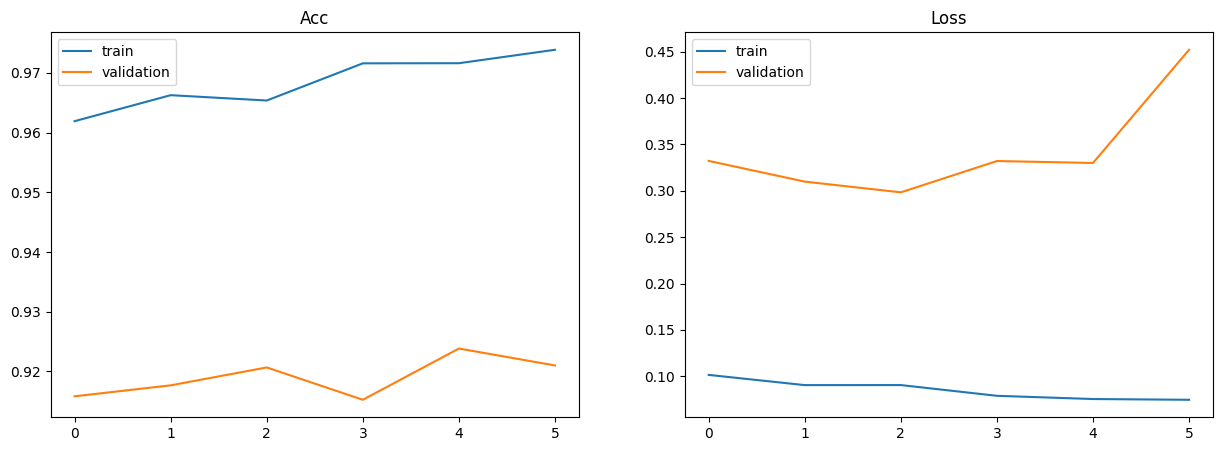

In [41]:
plot_history(history4.history)

In [42]:
pred=model4.predict(x_test[0:25])
print(np.round(pred, decimals=3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 893ms/step
[[0.    0.    0.    0.    0.    0.    0.    0.    0.    1.   ]
 [0.    0.    1.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.001 0.    0.    0.    0.001 0.    0.998 0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    1.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    1.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    1.    0.    0.   ]
 [0.    0.    0.    0.    1.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.137 0.    0.863 0.    0.   ]
 [0.    0.    0.    1.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.034 0.    0.966 0.    0.    0.    0.    0.   ]
 [0.    1.    0.

In [43]:
np.argmax(pred, axis=1)

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 6, 8, 0, 2, 5,
       7, 5, 1])

In [44]:
print(y_test[0:25])

[9 2 1 1 6 1 4 6 5 7 4 5 7 3 4 1 2 4 8 0 2 5 7 9 1]


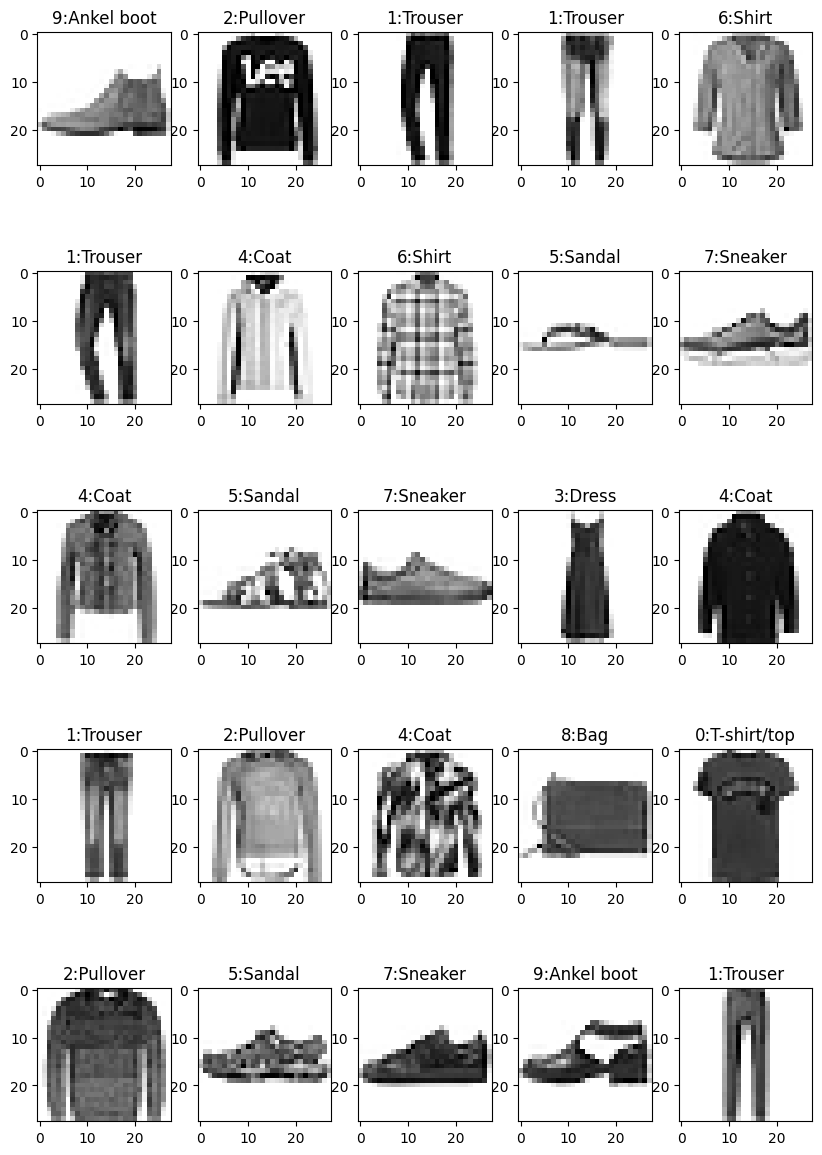

In [48]:
fig, axs = plt.subplots(5, 5, figsize=(10,15))
for i in range(5):
  for j in range(5):
    axs[i, j].set_title('{}:{}'.format(y_test[i*5+j], items[y_test[i*5+j]]))
    axs[i, j].imshow(x_test2d[i*5+j], cmap='gray_r')
plt.show()

## CNN의 시각화

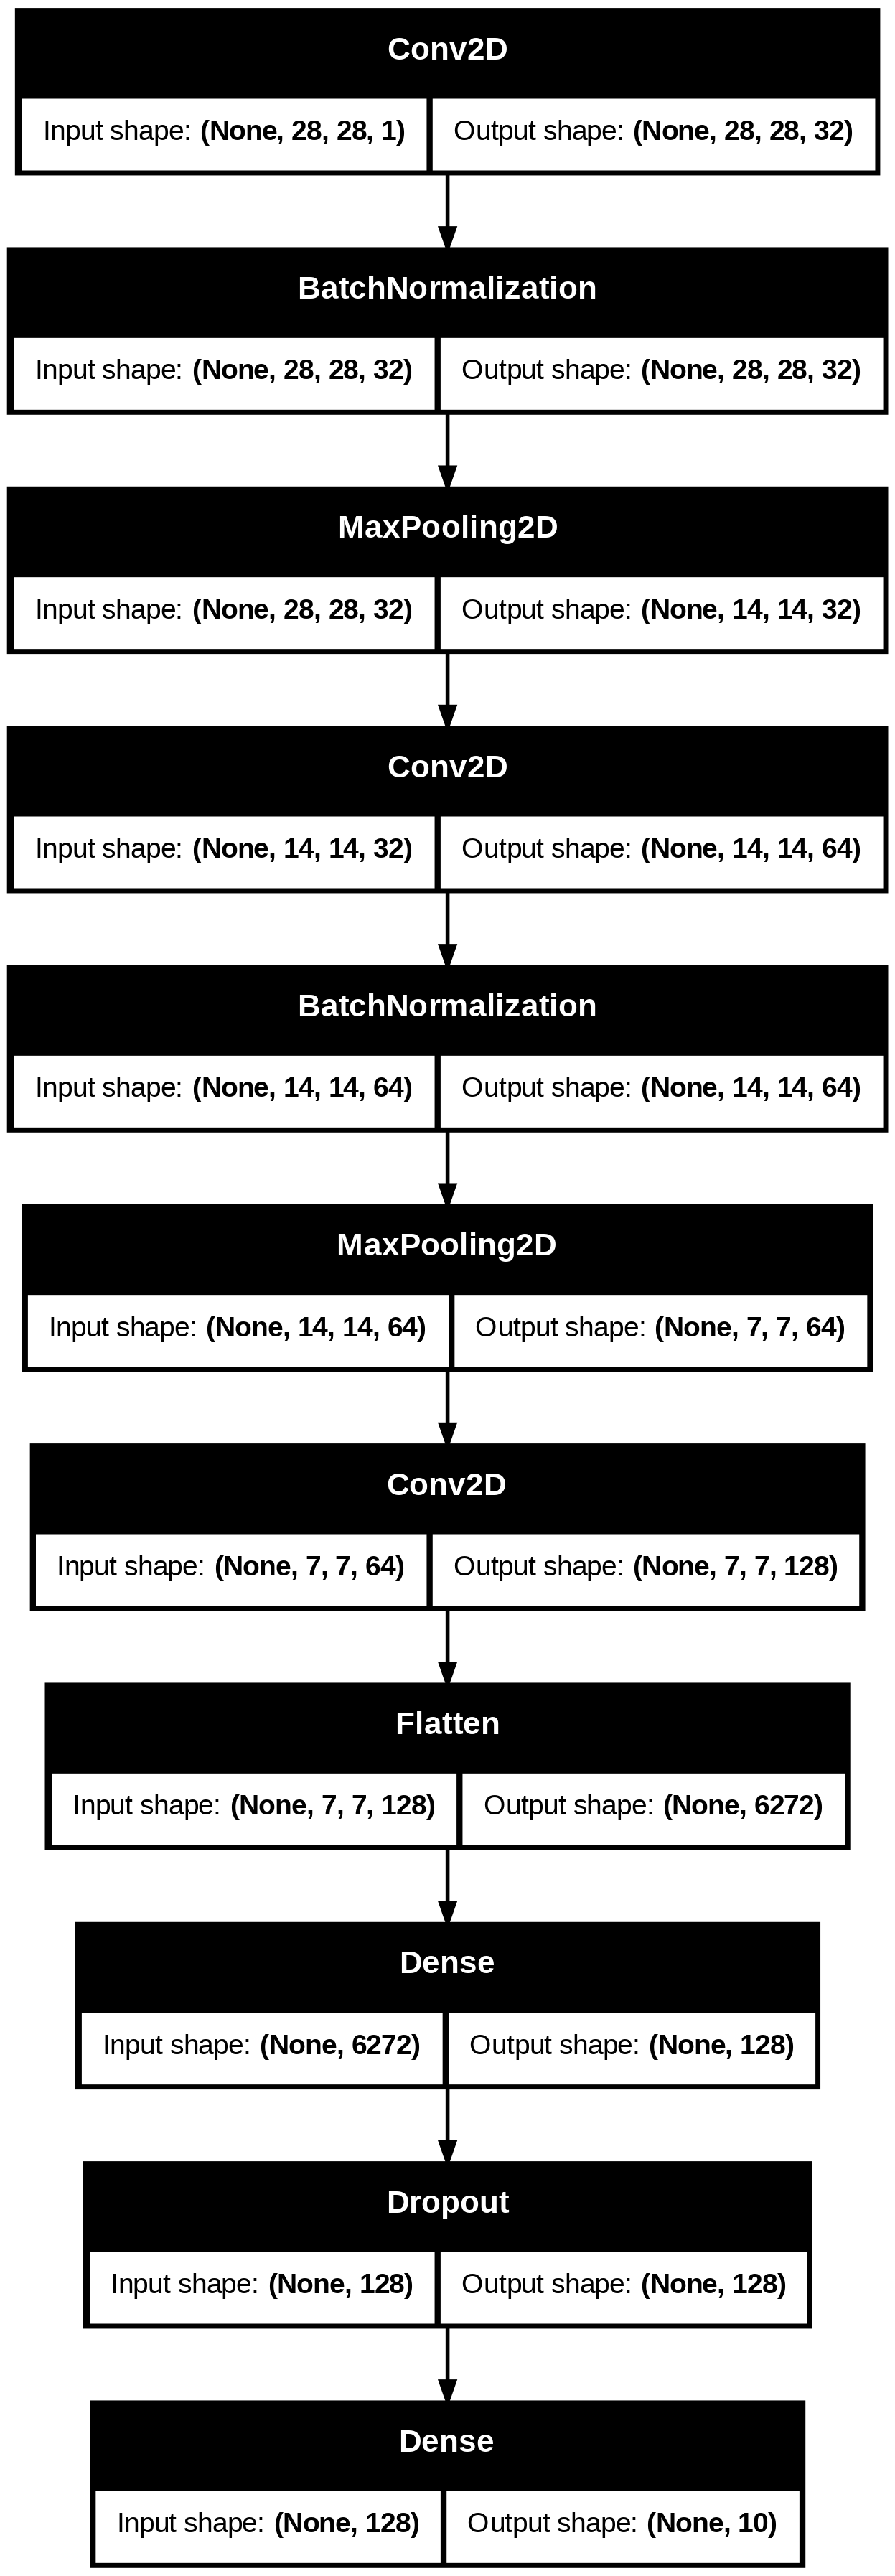

In [49]:
# 모델 구조를 그림으로 보여주는 함수
utils.plot_model(model4, show_shapes=True, to_file='fmnist.png')

### 학습된 Conv층 가져오기

In [50]:
model4.layers

[<Conv2D name=conv2d_9, built=True>,
 <BatchNormalization name=batch_normalization_4, built=True>,
 <MaxPooling2D name=max_pooling2d_6, built=True>,
 <Conv2D name=conv2d_10, built=True>,
 <BatchNormalization name=batch_normalization_5, built=True>,
 <MaxPooling2D name=max_pooling2d_7, built=True>,
 <Conv2D name=conv2d_11, built=True>,
 <Flatten name=flatten_3, built=True>,
 <Dense name=dense_6, built=True>,
 <Dropout name=dropout_3, built=True>,
 <Dense name=dense_7, built=True>]

In [52]:
conv = model4.layers[0]
print(conv.weights[0].shape, conv.weights[1].shape)
# (3, 3, 1, 32) : (필터 높이, 필터 너비, 입력 채널, 필터 개수) (bias)

(3, 3, 1, 32) (32,)


In [53]:
weights = conv.weights[0].numpy()
print(weights.shape)
print(weights)

(3, 3, 1, 32)
[[[[-1.01728804e-01 -9.73070636e-02  2.59439647e-01 -2.48748854e-01
     1.34699494e-01 -1.94943380e-02  1.85709774e-01 -9.91186202e-02
    -1.64464284e-02 -4.49452549e-02  1.74811363e-01  1.56876713e-01
    -9.70703736e-02  1.06428057e-01  2.01487511e-01 -1.89384401e-01
     1.60876885e-01  2.75888629e-02  2.03368440e-01  1.17317267e-01
     8.54576826e-02  1.73005670e-01 -7.78303444e-02 -1.77950293e-01
    -5.85375279e-02  1.81819394e-01 -5.27079888e-02 -3.13359141e-01
     1.78024799e-01 -1.26487076e-01  8.26346651e-02  1.99172586e-01]]

  [[-1.51355118e-01 -6.26051873e-02  1.11940764e-01 -4.92086541e-03
     5.75999431e-02 -1.03175557e+00  1.61864832e-01 -2.24427670e-01
    -2.93201841e-02 -1.45508945e-01 -2.34780774e-01  2.49361526e-02
     1.73490480e-01  6.11831397e-02 -4.62710932e-02 -7.39173472e-01
     6.30842075e-02  2.36787871e-02  1.96953595e-01  2.29552507e-01
    -1.13122746e-01 -1.56061918e-01  1.83788203e-02  1.28147855e-01
     3.70328838e-04  1.92398578

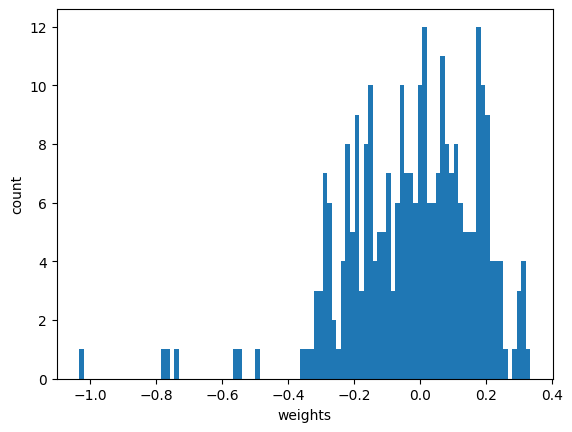

In [55]:
plt.hist(weights.flatten(), bins=100)
plt.xlabel('weights')
plt.ylabel('count')
plt.show()

In [56]:
weights[:, :, 0, 0] # 3,3,1,32 -> 3,3은 전부 가져오고 1, 32는 첫번째만

array([[-0.1017288 , -0.15135512, -0.14114504],
       [-0.00237762,  0.18874241,  0.19740476],
       [ 0.09621269,  0.05036285,  0.00131308]], dtype=float32)

In [57]:
weights[:, :, 0, 1]

array([[-0.09730706, -0.06260519, -0.20696966],
       [ 0.13662538,  0.30617768,  0.22413135],
       [-0.12716769, -0.1349116 ,  0.03828093]], dtype=float32)

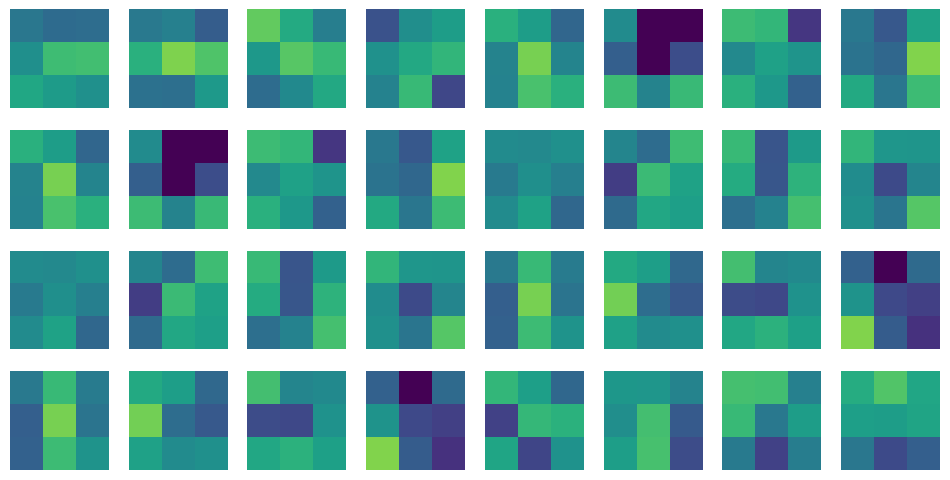

In [61]:
fig, axs = plt.subplots(4, 8, figsize=(12,6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(weights[:, :, 0, i*4+j], vmin=-0.5, vmax=0.5)
    axs[i, j].axis('off')
plt.show()

In [62]:
init_model = keras.Sequential()
init_model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)))
init_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
new_conv = init_model.layers[0]
print(new_conv.weights[0].shape, new_conv.weights[1].shape)

(3, 3, 1, 32) (32,)


In [67]:
new_weights = new_conv.weights[0].numpy()
print(new_weights.shape)
print(new_weights)

(3, 3, 1, 32)
[[[[ 0.03744842 -0.05985779  0.0980189   0.10626665 -0.09482791
     0.0638041   0.1420355  -0.08515815 -0.11280507  0.06918976
     0.10555975  0.10342492 -0.0309872   0.08495374  0.13125665
     0.08147897 -0.00784658 -0.02803229 -0.11573727  0.10191788
    -0.03014252  0.03663941  0.08669043  0.02888592  0.0865739
    -0.00295559  0.10517134  0.03234649  0.077601   -0.09824215
    -0.0415081   0.06674254]]

  [[-0.06443881 -0.03113979  0.04835443  0.10239172  0.03432594
    -0.02205063 -0.00178804 -0.03185546  0.10632157  0.02421746
    -0.12335521  0.09786078 -0.12806061 -0.02073052 -0.06840461
    -0.01784009 -0.03530383  0.04764459 -0.00589633  0.01640137
    -0.03369977 -0.05202659 -0.06892984  0.12314673 -0.01571491
     0.09326214 -0.04263584 -0.10290162 -0.02723939  0.09160806
    -0.01755869 -0.12124708]]

  [[ 0.14165838 -0.13602298 -0.03946594 -0.01089953  0.12411346
     0.09918097  0.10503656  0.09847069  0.05724579  0.11958729
     0.09376557 -0.08177846  

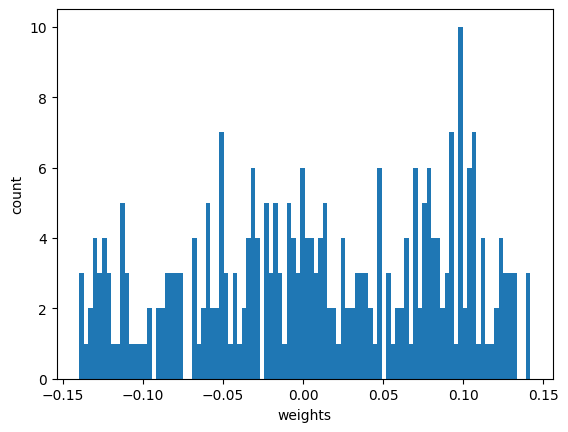

In [65]:
plt.hist(new_weights.flatten(), bins=100)
plt.xlabel('weights')
plt.ylabel('count')
plt.show()

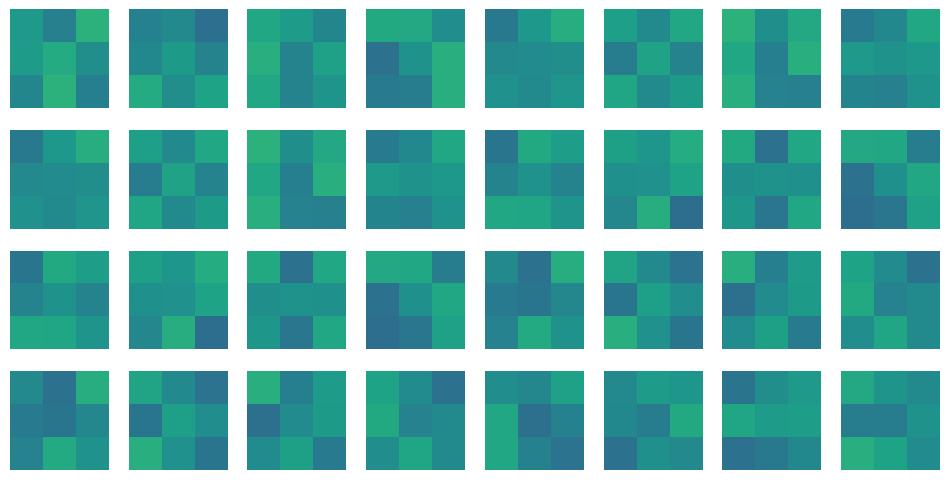

In [66]:
fig, axs = plt.subplots(4, 8, figsize=(12,6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(new_weights[:, :, 0, i*4+j], vmin=-0.5, vmax=0.5)
    axs[i, j].axis('off')
plt.show()

### 필터를 거친 이미지 확인하기

In [68]:
conv1 = keras.Model(model4.inputs[0], model4.layers[0].output) # 첫번째 층만으로 모델 만듬
conv1.summary()

Model: "functional_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

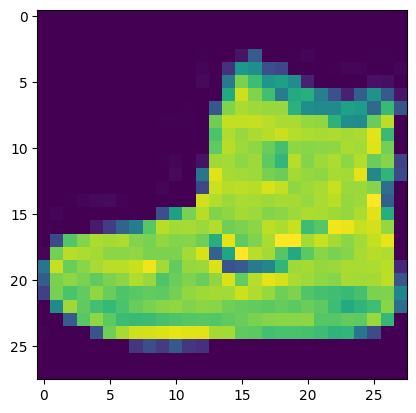

In [69]:
plt.imshow(x_train2d[0])

In [70]:
feature_map1 = conv1.predict(x_train[0:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step


In [71]:
print(feature_map1.shape)
# (1, 28, 28, 32) : (채널, 출력데이터크기, 출력데이터크기, 필터갯수)

(1, 28, 28, 32)


In [73]:
feature_map1[0, :, :, 2]

array([[0.06487565, 0.06487565, 0.06487565, 0.06487565, 0.06487565,
        0.06487565, 0.06487565, 0.06487565, 0.06487565, 0.06487565,
        0.06487565, 0.06487565, 0.06487565, 0.06487565, 0.06487565,
        0.06487565, 0.06487565, 0.06487565, 0.06487565, 0.06487565,
        0.06487565, 0.06487565, 0.06487565, 0.06487565, 0.06487565,
        0.06487565, 0.06487565, 0.06487565],
       [0.06487565, 0.06487565, 0.06487565, 0.06487565, 0.06487565,
        0.06487565, 0.06487565, 0.06487565, 0.06487565, 0.06487565,
        0.06487565, 0.06487565, 0.06487565, 0.06487565, 0.06487565,
        0.06487565, 0.06487565, 0.06487565, 0.06487565, 0.06487565,
        0.06487565, 0.06487565, 0.06487565, 0.06487565, 0.06487565,
        0.06487565, 0.06487565, 0.06487565],
       [0.06487565, 0.06487565, 0.06487565, 0.06487565, 0.06487565,
        0.06487565, 0.06487565, 0.06487565, 0.06487565, 0.06487565,
        0.06487565, 0.06527466, 0.06476898, 0.06430087, 0.0700627 ,
        0.0926162 , 0.0496

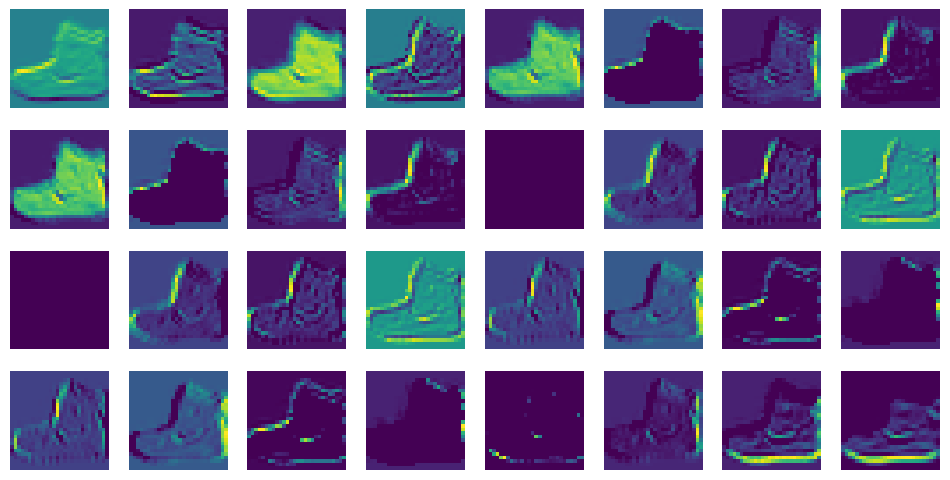

In [76]:
fig, axs = plt.subplots(4, 8, figsize=(12,6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(feature_map1[0, :, :, i*4+j])
    axs[i, j].axis('off')
plt.show()

In [77]:
model4.layers

[<Conv2D name=conv2d_9, built=True>,
 <BatchNormalization name=batch_normalization_4, built=True>,
 <MaxPooling2D name=max_pooling2d_6, built=True>,
 <Conv2D name=conv2d_10, built=True>,
 <BatchNormalization name=batch_normalization_5, built=True>,
 <MaxPooling2D name=max_pooling2d_7, built=True>,
 <Conv2D name=conv2d_11, built=True>,
 <Flatten name=flatten_3, built=True>,
 <Dense name=dense_6, built=True>,
 <Dropout name=dropout_3, built=True>,
 <Dense name=dense_7, built=True>]

In [78]:
conv2 = keras.Model(model4.inputs[0], model4.layers[3].output)
conv2.summary()

Model: "functional_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,944 (74.00 KB)

 Trainable params: 18,880 (73.75 KB)

 Non-trainable params: 64 (256.00 B)

In [79]:
feature_map2 = conv2.predict(x_train[0:1])
print(feature_map2.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step
(1, 14, 14, 64)


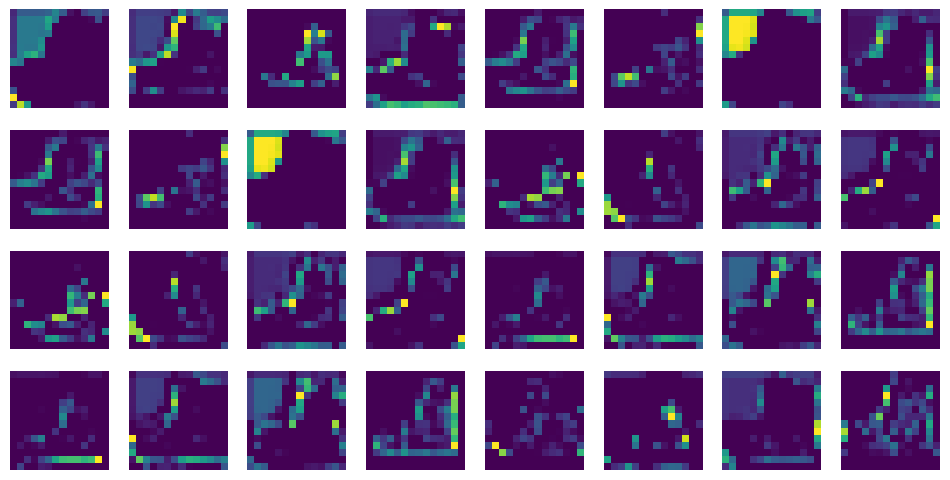

In [80]:
fig, axs = plt.subplots(4, 8, figsize=(12,6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(feature_map2[0, :, :, i*4+j])
    axs[i, j].axis('off')
plt.show()

In [81]:
model4.layers

[<Conv2D name=conv2d_9, built=True>,
 <BatchNormalization name=batch_normalization_4, built=True>,
 <MaxPooling2D name=max_pooling2d_6, built=True>,
 <Conv2D name=conv2d_10, built=True>,
 <BatchNormalization name=batch_normalization_5, built=True>,
 <MaxPooling2D name=max_pooling2d_7, built=True>,
 <Conv2D name=conv2d_11, built=True>,
 <Flatten name=flatten_3, built=True>,
 <Dense name=dense_6, built=True>,
 <Dropout name=dropout_3, built=True>,
 <Dense name=dense_7, built=True>]

In [82]:
conv3 = keras.Model(model4.inputs[0], model4.layers[6].output)
conv3.summary()

Model: "functional_45"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,056 (363.50 KB)

 Trainable params: 92,864 (362.75 KB)

 Non-trainable params: 192 (768.00 B)

In [83]:
feature_map3 = conv3.predict(x_train[0:1])
print(feature_map3.shape) # (1, 7, 7, 128)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
(1, 7, 7, 128)


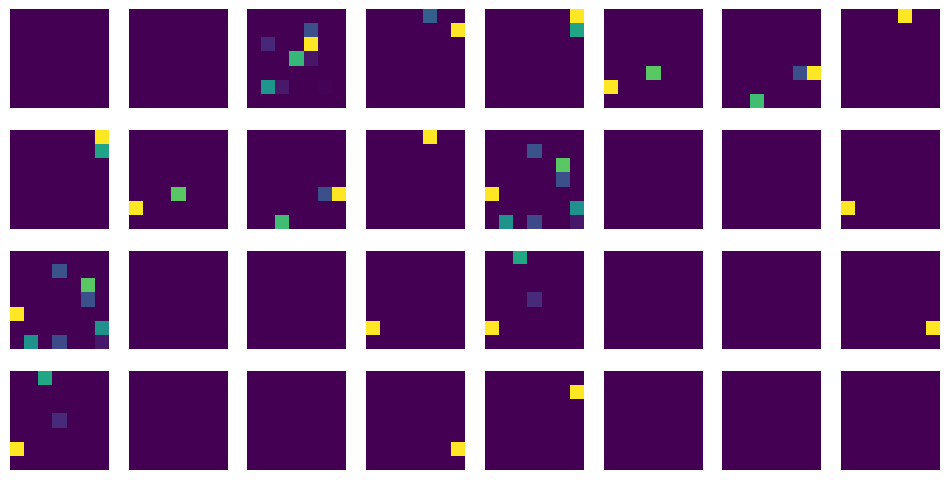

In [84]:
fig, axs = plt.subplots(4, 8, figsize=(12,6))
for i in range(4):
  for j in range(8):
    axs[i, j].imshow(feature_map3[0, :, :, i*4+j])
    axs[i, j].axis('off')
plt.show()